In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Load Metadata
df = pd.read_csv('../data/milk10k/metadata.csv')

# 1. Image & Lesion Scale Verification
total_images = len(df)
unique_lesions = df['lesion_id'].nunique()
print(f"Total Images: {total_images} (Target: 10,480)")
print(f"Unique Lesions: {unique_lesions} (Target: 5,240)")

# 2. Pairing Integrity Check
images_per_lesion = df.groupby('lesion_id').size()
is_perfectly_paired = (images_per_lesion == 2).all()
print(f"Are all lesions represented by exactly 2 images? {is_perfectly_paired}")

# Verify image types per pair (Dermoscopic vs. Clinical)
image_types = df.groupby(['lesion_id', 'image_type']).size().unstack(fill_value=0)
print("\nImage Type Distribution per Lesion Sample:")
print(image_types.head())

Total Images: 10480 (Target: 10,480)
Unique Lesions: 5240 (Target: 5,240)
Are all lesions represented by exactly 2 images? True

Image Type Distribution per Lesion Sample:
image_type  clinical: close-up  dermoscopic
lesion_id                                  
IL_0000652                   1            1
IL_0003176                   1            1
IL_0004688                   1            1
IL_0005081                   1            1
IL_0006177                   1            1


Data splits (Train/Val/Test) MUST be grouped by lesion_id using GroupKFold. Splitting randomly at the image level will cause data leakage because dermoscopic and clinical images of the exact same lesion would end up in both training and validation sets

/var/folders/8p/yrh_lyh11bng196gr45jj1qm0000gn/T/ipykernel_14252/2747598106.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df, x='diagnosis_1', palette='viridis')
/var/folders/8p/yrh_lyh11bng196gr45jj1qm0000gn/T/ipykernel_14252/2747598106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], data=df, x='diagnosis_2', palette='magma') # or training_gt column


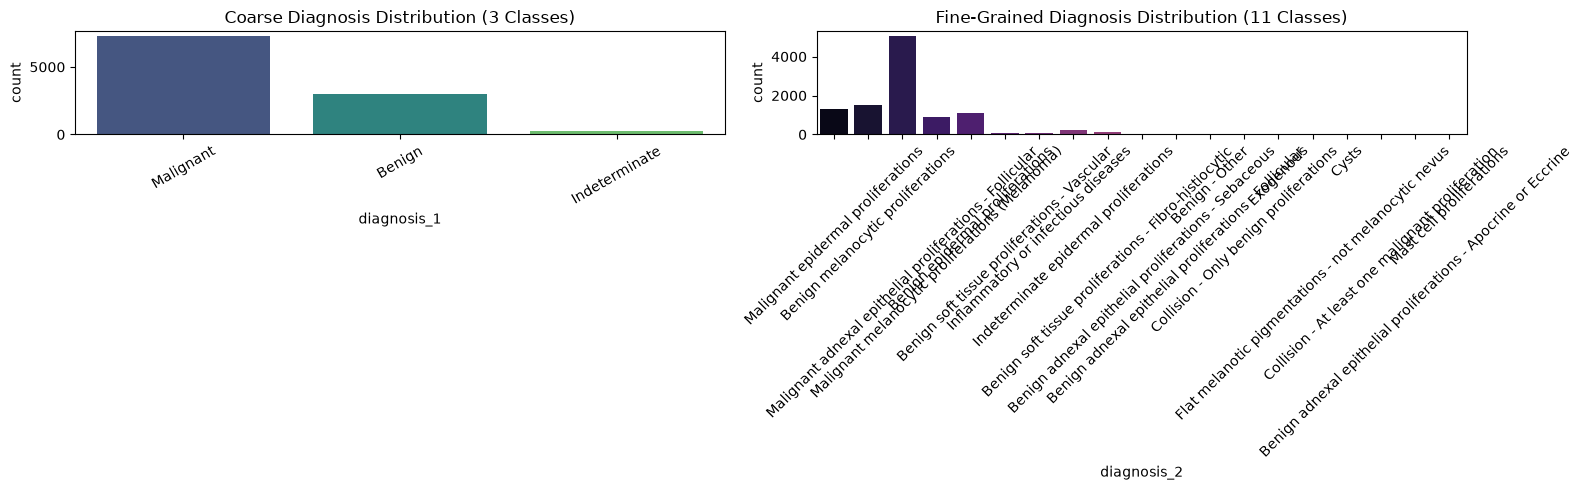

Class Frequencies:
 diagnosis_2
Malignant adnexal epithelial proliferations - Follicular          5044
Benign melanocytic proliferations                                 1492
Malignant epidermal proliferations                                1306
Benign epidermal proliferations                                   1090
Malignant melanocytic proliferations (Melanoma)                    900
Indeterminate epidermal proliferations                             246
Benign soft tissue proliferations - Fibro-histiocytic              112
Benign soft tissue proliferations - Vascular                        98
Inflammatory or infectious diseases                                 94
Flat melanotic pigmentations - not melanocytic nevus                18
Collision - At least one malignant proliferation                    18
Benign - Other                                                      16
Collision - Only benign proliferations                              14
Exogenous                                    

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3-Class Coarse Distribution
sns.countplot(ax=axes[0], data=df, x='diagnosis_1', palette='viridis')
axes[0].set_title('Coarse Diagnosis Distribution (3 Classes)')
axes[0].tick_params(axis='x', rotation=30)

# 11-Class Fine-Grained Distribution
sns.countplot(ax=axes[1], data=df, x='diagnosis_2', palette='magma') # or training_gt column
axes[1].set_title('Fine-Grained Diagnosis Distribution (11 Classes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Documenting Imbalance Ratio
class_counts = df['diagnosis_2'].value_counts()
print("Class Frequencies:\n", class_counts)

Document in a Markdown cell that severe imbalance between dominant classes (e.g., NV, BCC) and rare classes (e.g., VASC, DF) makes standard accuracy misleading. Specify Macro-F1 and Balanced Accuracy as the primary evaluation metrics.

/var/folders/8p/yrh_lyh11bng196gr45jj1qm0000gn/T/ipykernel_14252/595708865.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], data=df, x='sex', palette='Set2')
/var/folders/8p/yrh_lyh11bng196gr45jj1qm0000gn/T/ipykernel_14252/595708865.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1, 0], data=df, y='anatom_site_general', palette='Blues_r')


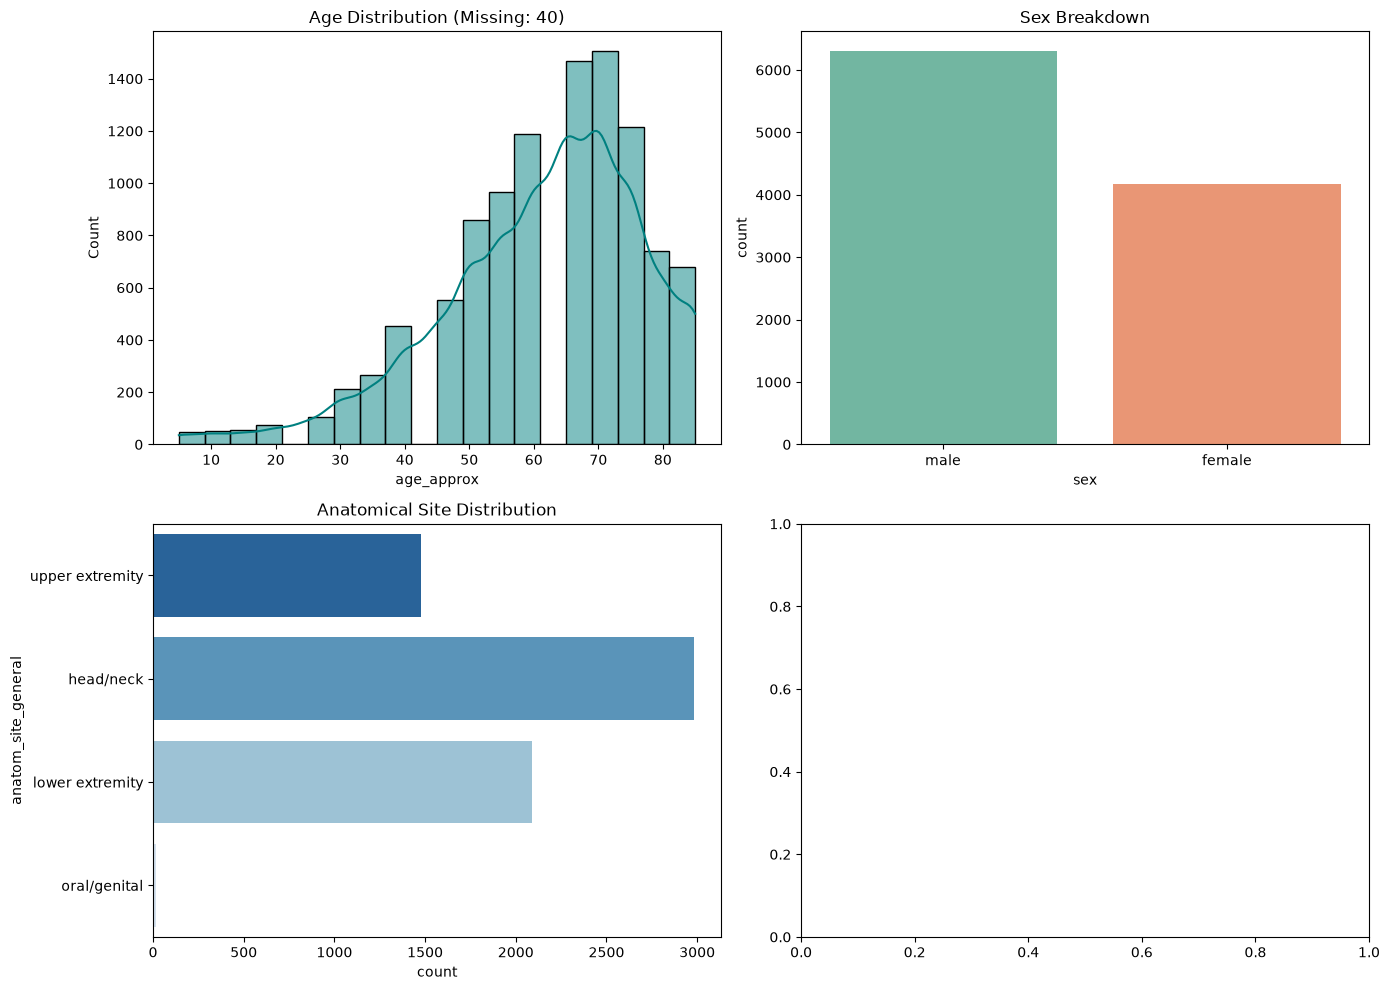

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age Distribution & Missing Values
sns.histplot(ax=axes[0, 0], data=df, x='age_approx', kde=True, bins=20, color='teal')
axes[0, 0].set_title(f'Age Distribution (Missing: {df["age_approx"].isnull().sum()})')

# Sex Distribution
sns.countplot(ax=axes[0, 1], data=df, x='sex', palette='Set2')
axes[0, 1].set_title('Sex Breakdown')

# Anatomical Site Frequencies
sns.countplot(ax=axes[1, 0], data=df, y='anatom_site_general', palette='Blues_r')
axes[1, 0].set_title('Anatomical Site Distribution')

# Fitzpatrick Skin Tone (Demographic Bias)
if 'fitzpatrick' in df.columns:
    sns.countplot(ax=axes[1, 1], data=df, x='fitzpatrick', palette='YlOrBr')
    axes[1, 1].set_title('Fitzpatrick Skin Tone Representation')

plt.tight_layout()
plt.show()

In [10]:
print(df.columns.tolist())

['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']


Image Dimensions -> Min: (600x450), Max: (600x450), Mean: (600x450)
Color Channels: {3} | Pixel Value Range: [0, 255] (uint8 verified)


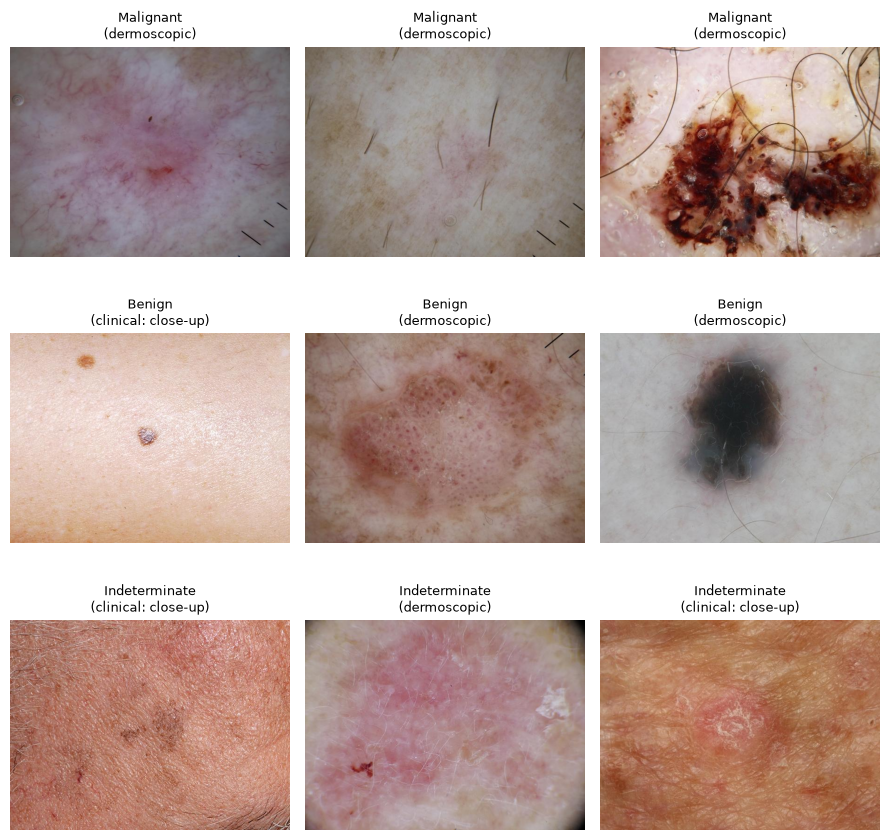

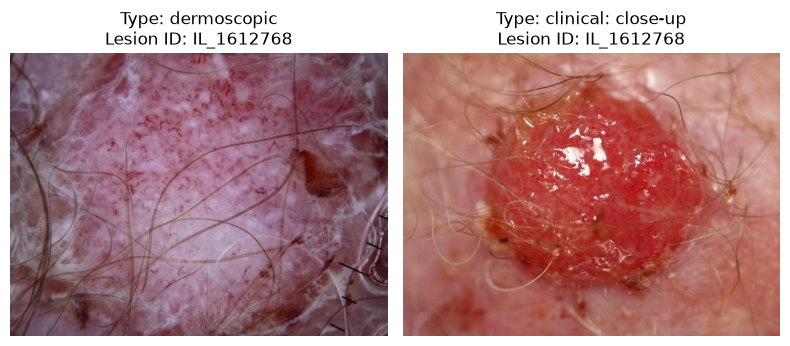

In [11]:
# 1. Pixel Inspection & Dimensions Loop
sample_df = df.sample(min(100, len(df)), random_state=42)
heights, widths, channels = [], [], []

for _, row in sample_df.iterrows():
    # Construct filename using isic_id
    img_name = f"{row['isic_id']}.jpg"
    full_path = os.path.join('../data/milk10k/images', img_name)
    
    img = cv2.imread(full_path)
    if img is not None:
        h, w, c = img.shape
        heights.append(h); widths.append(w); channels.append(c)

if heights:
    print(f"Image Dimensions -> Min: ({min(widths)}x{min(heights)}), Max: ({max(widths)}x{max(heights)}), Mean: ({np.mean(widths):.0f}x{np.mean(heights):.0f})")
    print(f"Color Channels: {set(channels)} | Pixel Value Range: [0, 255] (uint8 verified)")
else:
    print("Warning: Could not read sample images. Verify files are inside '../data/milk10k/images/'.")

# 2. Visual Grid Viewer Function
def show_samples(df, class_column='diagnosis_1', samples_per_class=3):
    classes = df[class_column].dropna().unique()
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(3 * samples_per_class, 3 * len(classes)))
    
    for i, cls in enumerate(classes):
        cls_df = df[df[class_column] == cls].sample(min(samples_per_class, len(df[df[class_column] == cls])), random_state=42)
        for j, (_, row) in enumerate(cls_df.iterrows()):
            img_path = os.path.join('../data/milk10k/images', f"{row['isic_id']}.jpg")
            img = Image.open(img_path)
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(f"{cls}\n({row['image_type']})", fontsize=9)
            ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(df, class_column='diagnosis_1', samples_per_class=3)

# 3. Paired Comparison Viewer (Dermoscopic vs. Clinical)
def show_paired_lesion(df, lesion_id):
    lesion_df = df[df['lesion_id'] == lesion_id]
    fig, axes = plt.subplots(1, len(lesion_df), figsize=(4 * len(lesion_df), 4))
    
    for idx, (_, row) in enumerate(lesion_df.iterrows()):
        img_path = os.path.join('../data/milk10k/images', f"{row['isic_id']}.jpg")
        img = Image.open(img_path)
        ax = axes[idx] if len(lesion_df) > 1 else axes
        ax.imshow(img)
        ax.set_title(f"Type: {row['image_type']}\nLesion ID: {lesion_id}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

sample_lesion = df['lesion_id'].iloc[0]
show_paired_lesion(df, sample_lesion)